# Fixed Effects

**Author:** Alejandro Orellana

**Date:** Janurary 14, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

## Section 1: Loading Data

In [ ]:
from utils.data_utils import load_data
from utils.fix_effect_utils import (
    fixed_effects_analysis,
    prepare_analysis,
    prepared_dataframe,
)
from utils.plot_utils import plot_fixed_effects_coefficients

panel_data = prepared_dataframe(load_data())
target_col = "Weather Normalized Site EUI (kBtu/sq ft)"
rating_col = "Chicago Energy Rating"
analysis_df = prepare_analysis(panel_data, target_col, rating_col)
analysis_df.head()

2026-01-24 09:23:18,542 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-01-24 09:23:18,545 [INFO] Category counts:
COVID Impact Category
Other                    985
Permanent               2370
Stable/Increased       10171
Temporary/Rebounded     5378


----------------------------------------
DATA ANALYSIS PREP SUMMARY
----------------------------------------
Initial Total Rows:        15320
Initial Unique Buildings:  1915
----------------------------------------
Rows with Future Change:   9904
Unique Buildings Retained: 1906
Unique Buildings Lost: 9
----------------------------------------


,Data Year,ID,Property Name,Address,ZIP Code,Community Area,Primary Property Type,Gross Floor Area - Buildings (sq ft),Year Built,# of Buildings,...,COVID Impact Category,Effective Year Built,Time Built,Current_EUI,Next_Year_EUI,Future_Change_Raw,Future_Change,Rating_Numeric,Rating_Cat,Post_Policy
11603,2016,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,194.6,186.9,-7.7,-7.7,NaN,None,0
2543,2017,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,186.9,186.5,-0.4,-0.4,NaN,None,0
28282,2018,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,186.5,NaN,NaN,NaN,NaN,None,0
20009,2019,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,309056.0,1928.0,3.0,...,Other,1928.0,1920-1960,NaN,180.0,NaN,NaN,NaN,None,1
6268,2020,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,505417.0,1928.0,3.0,...,Other,1928.0,1920-1960,180.0,175.3,-4.7,-4.7,NaN,None,1


# Fixed Effects Model

The prepare_analysis function constructs the target variable (Year-over-Year Change) and formats the Chicago Star Ratings. The fixed_effects_analysis function then models this data to isolate the specific impact of a building's Star Rating on its future performance, while controlling for natural mean reversion and city-wide COVID trends.

In [2]:
fe_model = fixed_effects_analysis(analysis_df)


--- Model: Two-Way Fixed Effects (Building & Year) ---
Using Reference Category: 0.0
                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     82.16
Date:                Sat, 24 Jan 2026   Prob (F-statistic):          2.54e-159
Time:                        09:23:19   Log-Likelihood:                -24773.
No. Observations:                6081   AIC:                         4.957e+04
Df Residuals:                    6068   BIC:                         4.966e+04
Df Model:                          12                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------

## Mean Reversion
The -0.04 coefficient for Current_EUI indicates mean reversion, suggesting that buildings can improve their energy use.

## Star Ratings
With a reference of 0 stars, it can be shown that there is evidence that for the lower stars will improve the most, but as the stars are higher, the less the building will improve. Showing there may be diminishing returns on a building improving based on the stars

## Covid
With the time-fix effect, there is a larger energy decrease in 2019, as the city increases its energy as it opens up again. Then it started to fall again, and the city has started to stabilize its energy use again in recent years

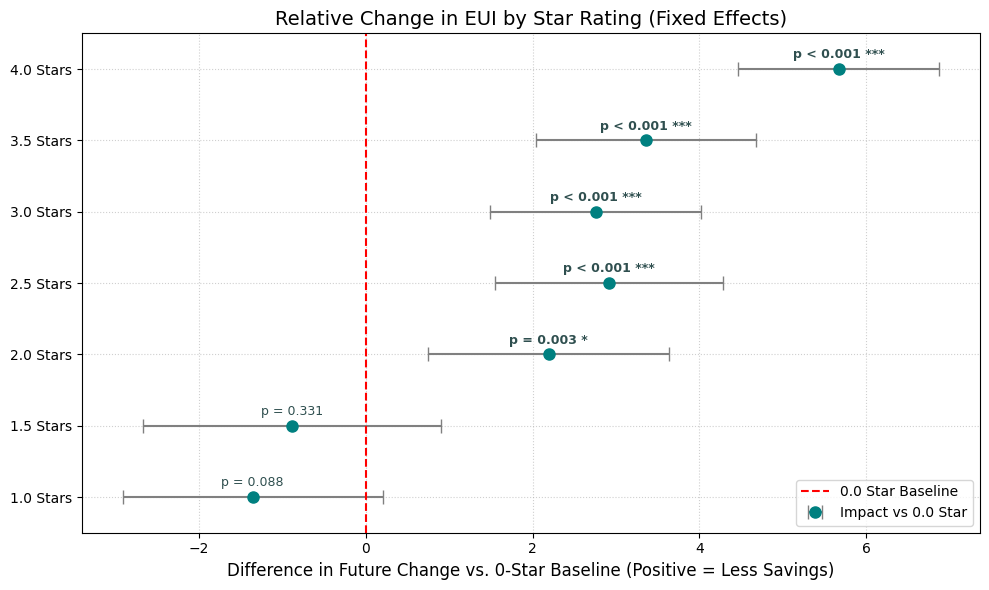

In [3]:
fig, ax = plot_fixed_effects_coefficients(fe_model)

This visualization plots the results, showing that as the star score increases, the EUI savings are predicted to decrease. For example, if a 1-star building decreases 10 Units for EUI, a 4-star building would be predicted to decrease 5 units for EUI. As 1-star buildings are around -1, and 4-star buildings are around 6 units saved.